<a href="https://colab.research.google.com/github/alunkingusw/meeting_diarisation/blob/master/tutorials/pyannote_3_4_0_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Powerset multi-class cross entropy loss for neural speaker diarization - Adapted for Colab 2025.10 build by Alun

This is the example notebook of the paper "*Powerset multi-class cross entropy loss for neural speaker diarization*", published at Interspeech 2023.

The corresponding official repository is available here

## Installing dependencies

Make sure you're **using a GPU** (Runtime -> Change runtime type) before starting the notebook.

Please download the ckpt file at https://github.com/FrenchKrab/IS2023-powerset-diarization/blob/master/models/powerset/powerset_pretrained.ckpt and place it in `/content/`.

**Restart the runtime once this part is complete** (Runtime -> Restart runtime) and then continue to next part, else you will encounter a pyannote.database error.

In [13]:
# Note: pyannote.audio's version is the oldest compatible version tested with this method.
# pyannote.database version 5.1 (newer) is used for convenience and ease of use.
!pip install -qq rich
!pip install -qq pyannote.audio==3.4.0
!pip install -qq pyannote.database==5.1

In [14]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Get Hugging Face secret token
from google.colab import userdata
HUGGING_FACE = userdata.get('HUGGING_FACE')


# download AMI-SDM mini corpus for testing
%cd /content/
!git clone https://github.com/pyannote/AMI-diarization-setup
%cp /content/AMI-diarization-setup/ /content/AMI-diarization-setup-SDM
%mv /content/AMI-diarization-setup/ /content/AMI-diarization-setup-IHM
%cd /content/AMI-diarization-setup-SDM/pyannote/
!bash download_ami_sdm_mini.sh

#download AMI-IHM mini corpus for training
!cd /content/AMI-diarization-setup-IHM/pyannote/
!bash download_ami_ihm_mini.sh

#download the AMI-

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'AMI-diarization-setup'...
remote: Enumerating objects: 977, done.
remote: Counting objects: 100% (977/977), done.
remote: Compressing objects: 100% (429/429), done.
remote: Total 977 (delta 390), reused 949 (delta 369), pack-reused 0 (from 0)
Receiving objects: 100% (977/977), 1.67 MiB | 5.76 MiB/s, done.
Resolving deltas: 100% (390/390), done.
/content/AMI-diarization-setup/pyannote
ES2002a.Array1-01.w 100%[===================>]  38.84M  14.1MB/s    in 2.7s    
2026-01-14 12:18:24 URL:https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/ES2002a/audio/ES2002a.Array1-01.wav [40727594/40727594] -> "amicorpus/ES2002a/audio/ES2002a.Array1-01.wav" [1]
ES2003a.Array1-01.w 100%[===================>]  34.78M  11.9MB/s    in 2.9s    
2026-01-14 12:18:28 URL:https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/ES2003a/audio/ES2003a.Arra

## Loading data and adapting the segmentation model to AMI mini

In [16]:
from pyannote.database import registry, FileFinder
#from drive
#registry.load_database("/content/drive/MyDrive/ColabFiles/new_training/AMI-diarization-setup-SDM/pyannote/database.yml")
#or, from local files
registry.load_database("/content/AMI-diarization-setup/pyannote/database.yml")
protocol = registry.get_protocol("AMI-SDM.SpeakerDiarization.mini", preprocessors={"audio": FileFinder()})

'AMI-SDM.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI-SDM.SpeakerDiarization.mini' found in /content/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.only_words' found in /content/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.mini' found in /content/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
'AMI.SpeakerDiarization.word_and_vocalsounds' found in /content/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.


/usr/local/lib/python3.12/dist-packages/pyannote/database/registry.py:499: UserWarning: Replacing existing AMI-SDM.SpeakerDiarization.only_words protocol by the one defined in '/content/AMI-diarization-setup/pyannote/database.yml'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyannote/database/registry.py:499: UserWarning: Replacing existing AMI-SDM.SpeakerDiarization.mini protocol by the one defined in '/content/AMI-diarization-setup/pyannote/database.yml'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyannote/database/registry.py:499: UserWarning: Replacing existing AMI.SpeakerDiarization.only_words protocol by the one defined in '/content/AMI-diarization-setup/pyannote/database.yml'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyannote/database/registry.py:499: UserWarning: Replacing existing AMI.SpeakerDiarization.mini protocol by the one defined in '/content/AMI-diarization-setup/pyannote/database.yml'.
  warnings.warn(
/usr/local/lib/python3.1

In [17]:
# Fix eventual locale errors with colab (happens when you want to use a command such as cd)
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [18]:
from pyannote.audio import Model
from pyannote.audio.tasks import SpeakerDiarization
import pyannote
import torch
import omegaconf, typing, collections
# The task Segmentation has been renamed to SpeakerDiarization in newer versions

PRETRAINED_PATH = "/content/drive/MyDrive/ColabFiles/new_training/powerset_pretrained.ckpt"

torch.serialization.add_safe_globals([omegaconf.listconfig.ListConfig])
torch.serialization.add_safe_globals([omegaconf.base.ContainerMetadata])
torch.serialization.add_safe_globals([typing.Any])
torch.serialization.add_safe_globals([list])
torch.serialization.add_safe_globals([collections.defaultdict])
torch.serialization.add_safe_globals([dict])
torch.serialization.add_safe_globals([int])
torch.serialization.add_safe_globals([omegaconf.nodes.AnyNode])
torch.serialization.add_safe_globals([omegaconf.base.Metadata])
torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])
torch.serialization.add_safe_globals([pyannote.audio.core.model.Introspection])
torch.serialization.add_safe_globals([pyannote.audio.core.task.Specifications])
torch.serialization.add_safe_globals([pyannote.audio.core.task.Problem])
torch.serialization.add_safe_globals([pyannote.audio.core.task.Resolution])

segmentation_model = Model.from_pretrained(PRETRAINED_PATH)
segmentation_model.task = SpeakerDiarization(protocol, duration=5.0, max_speakers_per_chunk=3, max_speakers_per_frame=2)
segmentation_model.task.prepare_data()
segmentation_model.task.setup()


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.6.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../drive/MyDrive/ColabFiles/new_training/powerset_pretrained.ckpt`
/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:178: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a 

Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.
Protocol AMI-SDM.SpeakerDiarization.mini does not precompute the output of torchaudio.info(): adding a 'torchaudio.info' preprocessor for you to speed up dataloaders. See pyannote.database documentation on how to do that yourself.


/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:284: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_uem, names=names, dtype=dtype, delim_whitespace=True)
/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:85: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  info = torchaudio.info(file["audio"], backend=backend)
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/soundfile_backend.py:120: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecat

The training should take a bit less than 15 minutes on a Google Colab T4 GPU

---



In [19]:
from types import MethodType
from torch.optim import Adam
# Updated to remove the Rich Progress Bar as it was causing a crash in Colab.
# I added print statements for each Epoch instead to update the user on progress.
from pytorch_lightning.callbacks import Callback
import time
from pytorch_lightning.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)
from pytorch_lightning import Trainer

# Class added to report epoch timings
class EpochTimer(Callback):
    def on_train_epoch_start(self, trainer, pl_module):
        # store the start time
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        elapsed = time.time() - self.epoch_start_time
        epoch = trainer.current_epoch
        print(f"✓ Finished epoch {epoch} — {elapsed:.2f} seconds")

# we use Adam optimizer with 1e-4 learning rate
def configure_optimizers(self):
    return Adam(self.parameters(), lr=1e-4)

segmentation_model.configure_optimizers = MethodType(configure_optimizers, segmentation_model)

# we monitor diarization error rate on the validation set
# and use to keep the best checkpoint and stop early
monitor, direction = segmentation_model.task.val_monitor
checkpoint = ModelCheckpoint(
    monitor=monitor,
    mode=direction,
    save_top_k=1,
    every_n_epochs=1,
    save_last=False,
    save_weights_only=False,
    filename="{epoch}",
    verbose=False,
)
early_stopping = EarlyStopping(
    monitor=monitor,
    mode=direction,
    min_delta=0.0,
    patience=10,
    strict=True,
    verbose=False,
)

callbacks = [checkpoint, early_stopping, EpochTimer()]

# we train for at most 20 epochs (might be shorter in case of early stopping)
# disable the progress bar, as it causes crashes for an unknown reason.
from pytorch_lightning import Trainer
trainer = Trainer(
    accelerator="gpu",
    callbacks=callbacks,
    max_epochs=20,
    gradient_clip_val=0.5,
    enable_progress_bar=False
)
trainer.fit(segmentation_model)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name              ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃      In sizes ┃                   Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ sincnet           │ SincNet          │ 42.6 K │ train │ 479 M │ [1, 1, 80000] │                [1, 60, 293] │
│ 1 │ lstm              │ LSTM             │  1.4 M │ train │     0 │  [1, 293, 60] │     [[1, 293, 256], [[8, 1, │
│   │                   │                  │        │       │       │               │         128], [8, 1, 128]]] │
│ 2 │ linear            │ ModuleList       │ 49.4 K │ train │     0 │             ? │                           ? │
│ 3 │ classifier        │ Linear           │    903 │ train │ 525 K │ [1, 293, 128] │                 [1, 293, 7] │
│ 4 │ activation        │ LogSoftmax       │      0 │ train │     0 │   [1, 293, 7] │                 [1, 293, 7] │
│ 5 │ powerset          │ Powerset         │      0 │ train │     0 │             ? │                           ? │
│ 6 │ validation_metric │ MetricCollection │      0 │ train │     0 │             ? │                           ? │
└───┴───────────────────┴──────────────────┴────────┴───────┴───────┴───────────────┴─────────────────────────────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 508 M

/usr/local/lib/python3.12/dist-packages/pyannote/audio/tasks/segmentation/mixins.py:60: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  file["torchaudio.info"] = AudioMetaData(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decode

✓ Finished epoch 0 — 21.66 seconds


...

✓ Finished epoch 17 — 22.20 seconds


/usr/local/lib/python3.12/dist-packages/pyannote/audio/tasks/segmentation/mixins.py:60: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  file["torchaudio.info"] = AudioMetaData(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decode

✓ Finished epoch 18 — 22.69 seconds


/usr/local/lib/python3.12/dist-packages/pyannote/audio/tasks/segmentation/mixins.py:60: UserWarning: torchaudio._backend.common.AudioMetaData has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  file["torchaudio.info"] = AudioMetaData(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decode

✓ Finished epoch 19 — 21.60 seconds


# Using the adapted segmentation model
## Segmentation model output

Path to the best checkpoint obtained from the adaption training.

In [20]:
checkpoint.best_model_path

'/content/AMI-diarization-setup/pyannote/lightning_logs/version_0/checkpoints/epoch=19.ckpt'

Compute and display the local segmentation models (pretrained and adapted) outputs over a sliding window.

In [21]:
from pyannote.audio import Inference
from pyannote.audio.pipelines.utils import get_devices

STEP = 5.0

(device,) = get_devices(needs=1)
file1 = next(protocol.test())

inf_pretrained = Inference(model=PRETRAINED_PATH, step=STEP, device=device)
inf_adapted = Inference(model=checkpoint.best_model_path, step=STEP, device=device)

local_out_pretrained = inf_pretrained(file1)
local_out_adapted = inf_adapted(file1)

/usr/local/lib/python3.12/dist-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _speechbrain_save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for _speechbrain_load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _save
DEBUG:speechbrain.utils.checkpoi

Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.


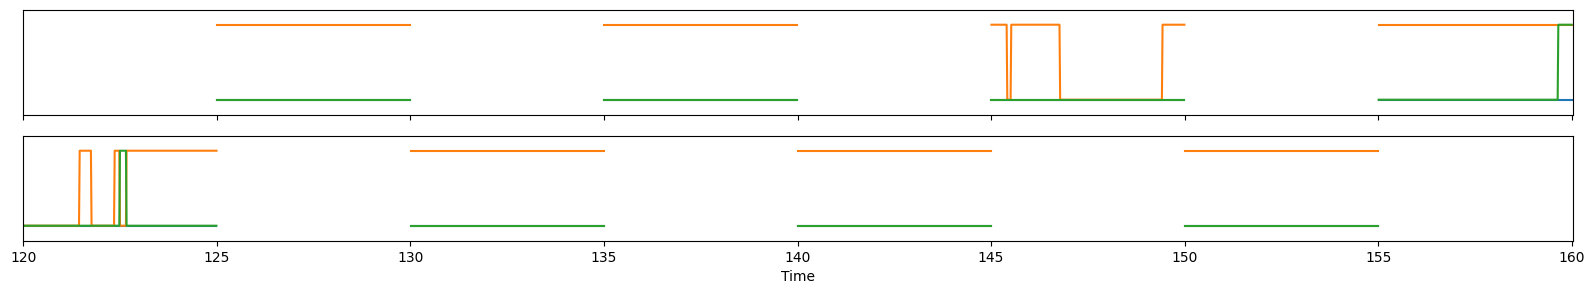

In [22]:
from pyannote.core import notebook, Segment
notebook.crop = Segment(120,160)

local_out_pretrained

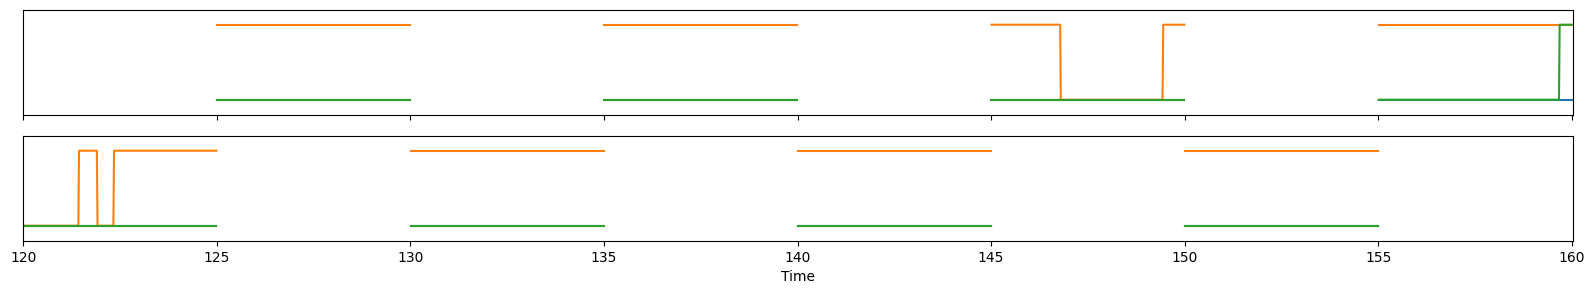

In [23]:
local_out_adapted

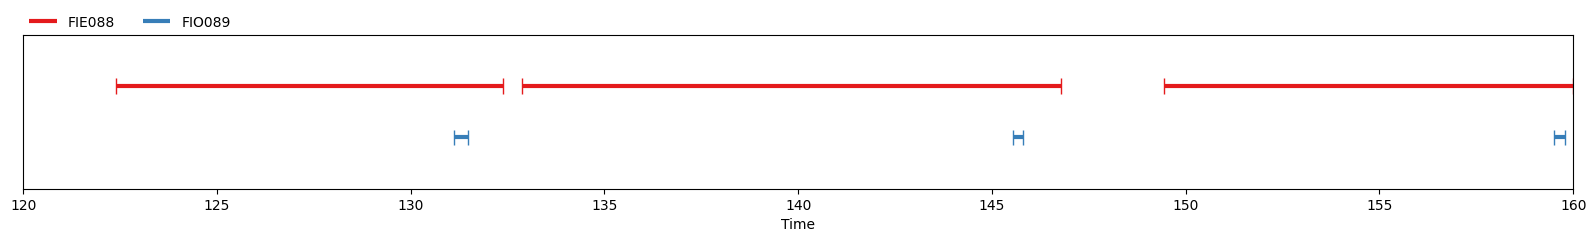

In [24]:
file1["annotation"]

## Adapted pipeline output
Now apply the full speaker diarization pipeline using the pretrained/adapted models to compare the outputs.
We can then observe the difference between pretrained/adapted/reference.

In [25]:
from pyannote.audio.pipelines import SpeakerDiarization as SpeakerDiarizationPipeline

STEP=5.0

# hyperparameters used for AMI
PIPELINE_PARAMS = {
    "clustering": {
        "method": "centroid",
        "min_cluster_size": 15,
        "threshold": 0.6285824248662424,
    },
    "segmentation": {
        "min_duration_off": 0.0,
    },
}

adapted_model = Model.from_pretrained(checkpoint.best_model_path)
pipeline_adapted = SpeakerDiarizationPipeline(adapted_model, embedding="speechbrain/spkrec-ecapa-voxceleb", clustering="AgglomerativeClustering").to(device)
pipeline_adapted.instantiate(PIPELINE_PARAMS)
out_adapted = pipeline_adapted(next(protocol.test()))

pipeline_pretrained = SpeakerDiarizationPipeline(PRETRAINED_PATH, embedding="speechbrain/spkrec-ecapa-voxceleb", clustering="AgglomerativeClustering").to(device)
pipeline_pretrained.instantiate(PIPELINE_PARAMS)
out_pretrained = pipeline_pretrained(next(protocol.test()))

/usr/local/lib/python3.12/dist-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will 

hyperparams.yaml: 0.00B [00:00, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/hyperparams.yaml' -> '/root/.cache/torch/pyannote/speechbrain/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
/usr/local/lib/python3.12/dist-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
DEBUG:speechbrain.utils.checkpoints:

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/embedding_model.ckpt' -> '/root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


...

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/classifier.ckpt' -> '/root/.cache/torch/pyannote/speechbrain/classifier.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["classifier"] = /root/.cache/torch/pyannote/speechbrain/classifier.ckpt
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt: 0.00B [00:00, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/label_encoder.txt' -> '/root/.cache/torch/pyannote/speechbrain/label_encoder.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["label_encoder"] = /root/.cache/torch/pyannote/speechbrain/label_encoder.ckpt
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): embedding_model -> /root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): mean_var_norm_emb -> /root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): classifier -> /root/.cac

Model was trained with pyannote.audio 2.1.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 2.x.
Model was trained with torch 1.13.0, yours is 2.8.0+cu126. Bad things might happen unless you revert torch to 1.x.


DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in /root/.cache/torch/pyannote/speechbrain.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /root/.cache/torch/pyannote/speechbrain/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /root/.cache/torch/pyannote/speechbrain/mean_var_norm_emb.ckpt
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Using symlink found at '/root/.cache/torch/pyannote/speechbrain/classifier.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["classifier"] = /root/.cache/torch/pyannote/speech

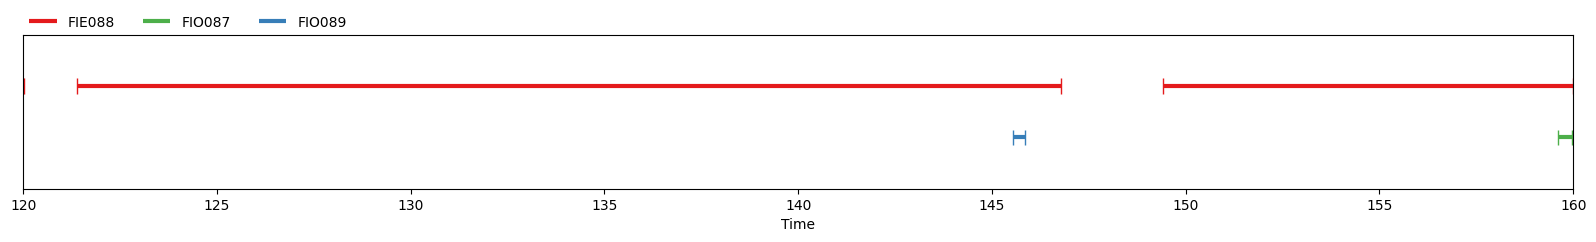

In [26]:
notebook.crop = Segment(120,160)

out_pretrained

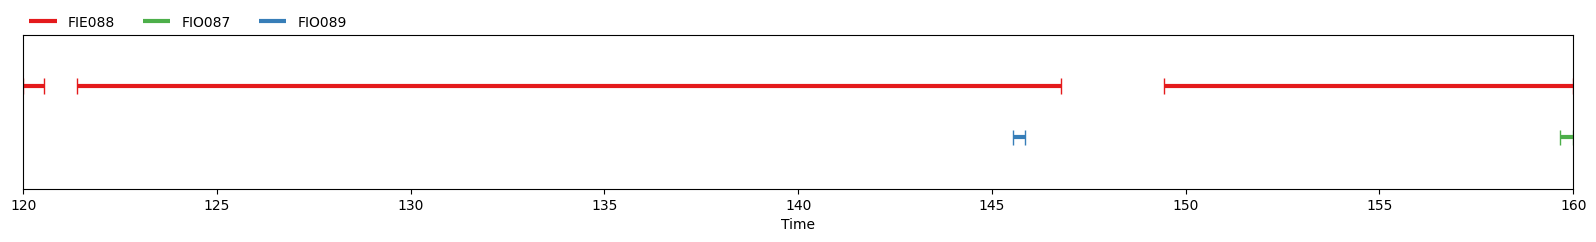

In [27]:
out_adapted

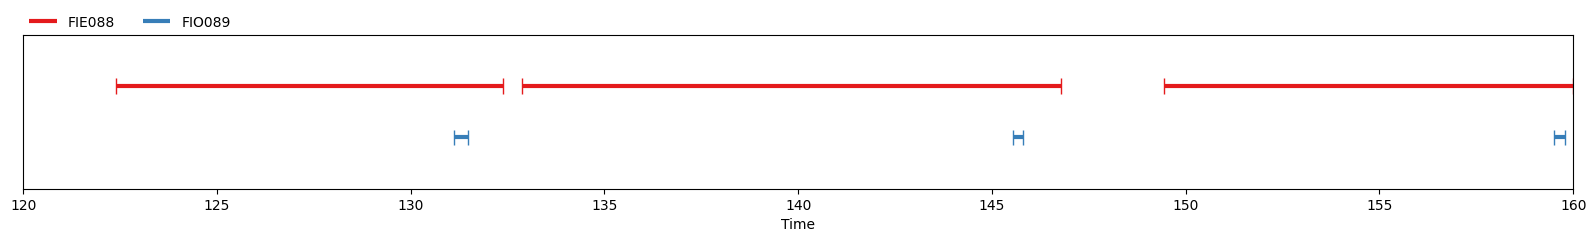

In [28]:
file1["annotation"]

## Evaluating the Diarization Error Rate (DER)

In [29]:
from pyannote.metrics.diarization import DiarizationErrorRate

def get_der(predictions, files):
  dermetric = DiarizationErrorRate()

  for file, pred in zip(files, predictions):
      # update der, computed between ground truth annotation and predicted
      # speech, on the file's uem.
      _ = dermetric(file["annotation"], pred, uem=file["annotated"])

  false_alarm = dermetric["false alarm"] / dermetric["total"]
  missed = dermetric["missed detection"] / dermetric["total"]
  confusion = dermetric["confusion"] / dermetric["total"]
  der = abs(dermetric)

  return false_alarm, missed, confusion, der


res_pt = {}
res_pt["fa"], res_pt["miss"], res_pt["conf"], res_pt["der"] = get_der([out_pretrained], [file1])

res_ad = {}
res_ad["fa"], res_ad["miss"], res_ad["conf"], res_ad["der"] = get_der([out_adapted], [file1])

print(f"On the first file of AMI mini ({file1['uri']}):")
print(f"{'Title':10} | {'FA%':>6} | {'MISS%':>6} | {'CONF%':>6} | {'DER%':>6}")
print(f"{'Pretrained':10} | {res_pt['fa']*100:6.2f} | {res_pt['miss']*100:6.2f} | {res_pt['conf']*100:6.2f} | {res_pt['der']*100:6.2f}")
print(f"{'Adapted':10} | {res_ad['fa']*100:6.2f} | {res_ad['miss']*100:6.2f} | {res_ad['conf']*100:6.2f} | {res_ad['der']*100:6.2f}")

On the first file of AMI mini (IS1009a):
Title      |    FA% |  MISS% |  CONF% |   DER%
Pretrained |   8.14 |   7.51 |  15.50 |  31.14
Adapted    |   7.38 |   7.01 |  10.34 |  24.73
